# TP1 - Un primer encuentro con la EPH
### Taller de Programación (UBA) 2026 - Grupo 8: *Informal self-employed*

**Docente:** Noelia Romero

**Integrantes:** Mayra Lemes Lapasta y Javier Hernández Aldana

**Repositorio:** https://github.com/maylemes/TPs_Programacion_Grupo8


In [2]:
# Instalación de paquetes y librerías:
#Paquetes
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para ver todas las columnas al inspeccionar los dataframes
pd.set_option('display.max_columns', None)

print("Librerías cargadas. pandas", pd.__version__)

Librerías cargadas. pandas 2.3.3


## Parte I: Familiarizándonos con la base EPH y limpieza

### Inciso 2. Descarga, selección y armonización de variables

Los datos provienen de la **Encuesta Permanente de Hogares (EPH)** que releva el Instituto Nacional de Estadística y Censos (INDEC). Se descargaron las bases individuales correspondientes al 4° trimestre de 2024 y 2025 desde la sección *Servicios y Herramientas → Bases de datos* del sitio oficial (https://www.indec.gob.ar/), junto con sus respectivos diccionarios de registro ("Diseño de registro y estructura para las bases preliminares").

A partir de ellas se seleccionaron 20 variables de interés (más las de identificación), y se verificó la consistencia de nombres y tipos de dato entre ambos años antes de combinarlas en una única base.

*Fuente: INDEC, Encuesta Permanente de Hogares.*

In [5]:
# Carga de las bases individuales (4T2024 y 4T2025)
df24 = pd.read_excel('bases/usu_individual_T424.xlsx')
df25 = pd.read_excel('bases/usu_individual_T425.xlsx')

print("2024T4:", df24.shape)
print("2025T4:", df25.shape)

2024T4: (46860, 235)
2025T4: (43703, 235)


In [6]:
df24.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,CH03,CH04,CH05,CH06,CH07,CH08,CH09,CH10,CH11,CH12,CH13,CH14,CH15,CH15_COD,CH16,CH16_COD,NIVEL_ED,ESTADO,CAT_OCUP,CAT_INAC,IMPUTA,PP02C1,PP02C2,PP02C3,PP02C4,PP02C5,PP02C6,PP02C7,PP02C8,PP02E,PP02H,PP02I,PP03C,PP03D,PP3E_TOT,PP3F_TOT,PP03G,PP03H,PP03I,PP03J,INTENSI,PP04A,PP04B_COD,PP04B1,PP04B2,PP04B3_MES,PP04B3_ANO,PP04B3_DIA,PP04C,PP04C99,PP04D_COD,PP04G,PP05B2_MES,PP05B2_ANO,PP05B2_DIA,PP05C_1,PP05C_2,PP05C_3,PP05E,PP05F,PP05H,PP06A,PP06C,PP06D,PP06E,PP06H,PP07A,PP07C,PP07D,PP07E,PP07F1,PP07F2,PP07F3,PP07F4,PP07F5,PP07G1,PP07G2,PP07G3,PP07G4,PP07G_59,PP07H,PP07I,PP07J,PP07K,PP08D1,PP08D4,PP08F1,PP08F2,PP08J1,PP08J2,PP08J3,PP09A,PP09A_ESP,PP09B,PP09C,PP09C_ESP,PP10A,PP10C,PP10D,PP10E,PP11A,PP11B_COD,PP11B1,PP11B2_MES,PP11B2_ANO,PP11B2_DIA,PP11C,PP11C99,PP11D_COD,PP11G_ANO,PP11G_MES,PP11G_DIA,PP11L,PP11L1,PP11M,PP11N,PP11O,PP11P,PP11Q,PP11R,PP11S,PP11T,P21,DECOCUR,IDECOCUR,RDECOCUR,GDECOCUR,PDECOCUR,ADECOCUR,PONDIIO,TOT_P12,P47T,DECINDR,IDECINDR,RDECINDR,GDECINDR,PDECINDR,ADECINDR,PONDII,V3_M,V4_M,V8_M,V9_M,V10_M,V12_M,V18_M,V19_AM,T_VI,ITF,DECIFR,IDECIFR,RDECIFR,GDECIFR,PDECIFR,ADECIFR,IPCF,DECCFR,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PONDIH,V2_02_M,V2_03_M,V5_03_M,V11_02_M,PP07B1_01,EMPLEO,SECTOR,PP02A,PP02B,PP02D,PP02F,PP02G,PP03K,PP04A1,PP05B3,PP05I,PP05J,PP05K,PP06E1,PP06K,PP06K_SEM,PP06K_MES,PP06L,PP07F1_1,PP07F1_2,PP07F1_3,PP07I2,PP07I3,PP07I4,PP07L,PP07M,PP08G,PP08G_DSEM,PP08G_DMES,PP08H,PP10B1,PP10B2,PP10B3,PP10B4,PP10B5,PP10B6,PP10B7,PP10B8,PP10B9,PP10B10,PP11L2,V2_01_M,V5_01_M,V5_02_M,V11_01_M,V21_01_M,V21_02_M,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNORTSHJKLMCDEHPJB00872828,2024,4,1,2,1,40,S,29,384,2,1,1945-03-22 00:00:00,79,2,1,1,2,0,6,1,NaN,3,6.0,1,NaN,6,3,0,1,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,NaN,0,384,0,290000.0,3,3.0,4,3.0,NaN,4,498,0,0,0,0,0,0,0,0,290000,1078000,6,6.0,7,6.0,NaN,7,539000.0,7,8.0,9,7.0,NaN,9,586,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220000,0,0,0,0,0,0,70000,0,0,8.0,9.0,8.0,NaN,8.0,10.0
1,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,1,1,40,S,29,265,1,2,2001-11-05 00:00:00,23,5,1,1,1,1,7,2,2.0,3,66.0,1,NaN,5,3,0,3,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,NaN,0,265,0,120000.0,1,1.0,2,1.0,NaN,2,318,0,0,0,0,0,120000,0,0,120000,0,12,12.0,12,12.0,NaN,12,0.0,12,12.0,12,12.0,NaN,12,0,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,2,1,40,S,29,265,10,2,2004-03-02 00:00:00,20,5,4,1,1,1,7,2,0.0,3,66.0,1,NaN,5,3,0,3,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,NaN,0,265,0,-9.0,12,12.0,12,12.0

In [7]:
# Chequeamos si están las variables obligatorias que se solicitan en el trabajo
obligatorias = ['CH04','CH06','CH07','CH08','NIVEL_ED','ESTADO','CAT_OCUP',
                'EMPLEO','SECTOR','PP04C','PP04D_COD','P21','P47T']

for v in obligatorias:
    print(v, "-> 2024:", v in df24.columns, " 2025:", v in df25.columns)

CH04 -> 2024: True  2025: True
CH06 -> 2024: True  2025: True
CH07 -> 2024: True  2025: True
CH08 -> 2024: True  2025: True
NIVEL_ED -> 2024: True  2025: True
ESTADO -> 2024: True  2025: True
CAT_OCUP -> 2024: True  2025: True
EMPLEO -> 2024: True  2025: True
SECTOR -> 2024: True  2025: True
PP04C -> 2024: True  2025: True
PP04D_COD -> 2024: True  2025: True
P21 -> 2024: True  2025: True
P47T -> 2024: True  2025: True


In [8]:
# Columnas que están en un año pero no en el otro
solo_24 = set(df24.columns) - set(df25.columns)
solo_25 = set(df25.columns) - set(df24.columns)

print("Solo en 2024:", solo_24)
print("Solo en 2025:", solo_25)

Solo en 2024: set()
Solo en 2025: set()


In [10]:
#  Cruzamos con la categoría ocupacional para ver quien responde cada variable
ocup = df24[df24['ESTADO'] == 1]
indep = ocup[ocup['CAT_OCUP'].isin([1,2])]   # patrones y cuentapropia
asal  = ocup[ocup['CAT_OCUP'] == 3]          # asalariados

for v in ['PP07H', 'PP07I', 'PP05I', 'PP05K']:
    print(f"\n===== {v} =====")
    print("-- Independientes (cat 1 y 2):")
    print(indep[v].value_counts(dropna=False).sort_index())
    print("-- Asalariados (cat 3):")
    print(asal[v].value_counts(dropna=False).sort_index())


===== PP07H =====
-- Independientes (cat 1 y 2):
PP07H
0.0    5746
Name: count, dtype: int64
-- Asalariados (cat 3):
PP07H
1.0    9727
2.0    5565
Name: count, dtype: int64

===== PP07I =====
-- Independientes (cat 1 y 2):
PP07I
0.0    5746
Name: count, dtype: int64
-- Asalariados (cat 3):
PP07I
0.0    9787
1.0     694
2.0    4811
Name: count, dtype: int64

===== PP05I =====
-- Independientes (cat 1 y 2):
PP05I
1.0    1790
2.0      68
3.0     346
4.0    3536
9.0       6
Name: count, dtype: int64
-- Asalariados (cat 3):
PP05I
0.0    15232
1.0       20
2.0        3
3.0        5
4.0       28
9.0        4
Name: count, dtype: int64

===== PP05K =====
-- Independientes (cat 1 y 2):
PP05K
0.0    2204
1.0     122
2.0    3353
9.0      67
Name: count, dtype: int64
-- Asalariados (cat 3):
PP05K
0.0    15260
1.0        1
2.0       25
9.0        6
Name: count, dtype: int64


In [11]:
# Variables de identificación (obligatorias, no cuentan entre las 20 de interés):
vars_id = ['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'PONDERA']

# Las 13 obligatorias del punto 2
vars_obligatorias = ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO',
                     'CAT_OCUP', 'EMPLEO', 'SECTOR', 'PP04C', 'PP04D_COD',
                     'P21', 'P47T']

# 7 variables de interés que elegimos: 
vars_elegidas = ['PP05I',      # aportes jubilatorios del independiente 
                 'PP05K',      # emite factura / registro de la actividad
                 'PP04A',      # sector: estatal / privado / otro
                 'PP3E_TOT',   # horas trabajadas (para salario horario)
                 'INTENSI',    # sub / pleno / sobreocupación
                 'AGLOMERADO', # heterogeneidad geográfica
                 'PONDIIO']    # ponderador del ingreso de la ocupación principal

# Lista final: todas las columnas que vamos a conservar
columnas = vars_id + vars_obligatorias + vars_elegidas
print("Total de columnas seleccionadas:", len(columnas))
print("De interés (sin las de ID):", len(vars_obligatorias + vars_elegidas))

Total de columnas seleccionadas: 25
De interés (sin las de ID): 20


In [12]:
# Nos quedamos solo con las columnas seleccionadas, en cada año
df24_sel = df24[columnas].copy()
df25_sel = df25[columnas].copy()

# Apilamos las dos bases en una sola 
eph = pd.concat([df24_sel, df25_sel], ignore_index=True)

print("Base combinada:", eph.shape)
print(eph.groupby('ANO4').size())

Base combinada: (90563, 25)
ANO4
2024    46860
2025    43703
dtype: int64


In [13]:
# Comparar el tipo de dato de cada columna entre los dos años
tipos = pd.DataFrame({
    'tipo_2024': df24_sel.dtypes,
    'tipo_2025': df25_sel.dtypes
})
tipos['coincide'] = tipos['tipo_2024'] == tipos['tipo_2025']

# Mostrar solo las que NO coinciden
print("Variables con tipo distinto entre años:")
print(tipos[~tipos['coincide']])

Variables con tipo distinto entre años:
Empty DataFrame
Columns: [tipo_2024, tipo_2025, coincide]
Index: []


In [14]:
# tipo para cada variable en la base combinada
print(eph.dtypes)


CODUSU         object
ANO4            int64
TRIMESTRE       int64
NRO_HOGAR       int64
PONDERA         int64
CH04            int64
CH06            int64
CH07            int64
CH08            int64
NIVEL_ED        int64
ESTADO          int64
CAT_OCUP        int64
EMPLEO        float64
SECTOR        float64
PP04C         float64
PP04D_COD     float64
P21             int64
P47T          float64
PP05I         float64
PP05K         float64
PP04A         float64
PP3E_TOT      float64
INTENSI       float64
AGLOMERADO      int64
PONDIIO         int64
dtype: object


In [15]:
# Exploración de la base combinada 
print('Columnas:', eph.columns)
print('\nTipo de dato (Types):\n', eph.dtypes)
print('\nTamaño de la base (Shape):', eph.shape)

Columnas: Index(['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'PONDERA', 'CH04', 'CH06',
       'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'EMPLEO', 'SECTOR',
       'PP04C', 'PP04D_COD', 'P21', 'P47T', 'PP05I', 'PP05K', 'PP04A',
       'PP3E_TOT', 'INTENSI', 'AGLOMERADO', 'PONDIIO'],
      dtype='object')

Tipo de dato (Types):
 CODUSU         object
ANO4            int64
TRIMESTRE       int64
NRO_HOGAR       int64
PONDERA         int64
CH04            int64
CH06            int64
CH07            int64
CH08            int64
NIVEL_ED        int64
ESTADO          int64
CAT_OCUP        int64
EMPLEO        float64
SECTOR        float64
PP04C         float64
PP04D_COD     float64
P21             int64
P47T          float64
PP05I         float64
PP05K         float64
PP04A         float64
PP3E_TOT      float64
INTENSI       float64
AGLOMERADO      int64
PONDIIO         int64
dtype: object

Tamaño de la base (Shape): (90563, 25)


In [16]:
eph.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90563 entries, 0 to 90562
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CODUSU      90563 non-null  object 
 1   ANO4        90563 non-null  int64  
 2   TRIMESTRE   90563 non-null  int64  
 3   NRO_HOGAR   90563 non-null  int64  
 4   PONDERA     90563 non-null  int64  
 5   CH04        90563 non-null  int64  
 6   CH06        90563 non-null  int64  
 7   CH07        90563 non-null  int64  
 8   CH08        90563 non-null  int64  
 9   NIVEL_ED    90563 non-null  int64  
 10  ESTADO      90563 non-null  int64  
 11  CAT_OCUP    90563 non-null  int64  
 12  EMPLEO      40830 non-null  float64
 13  SECTOR      40830 non-null  float64
 14  PP04C       40830 non-null  float64
 15  PP04D_COD   40830 non-null  float64
 16  P21         90563 non-null  int64  
 17  P47T        90442 non-null  float64
 18  PP05I       40830 non-null  float64
 19  PP05K       40830 non-nul

In [17]:
#  Buscamos negativos o códigos raros para ingresos
print("--- P21 (ingreso ocupación principal) ---")
print(eph['P21'].describe())
print("\n¿Hay valores negativos en P21?:", (eph['P21'] < 0).sum())

print("\n--- P47T (ingreso total) ---")
print(eph['P47T'].describe())
print("\n¿Hay valores negativos en P47T?:", (eph['P47T'] < 0).sum())

--- P21 (ingreso ocupación principal) ---
count    9.056300e+04
mean     2.770813e+05
std      5.982386e+05
min     -9.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.000000e+05
max      3.000000e+07
Name: P21, dtype: float64

¿Hay valores negativos en P21?: 8189

--- P47T (ingreso total) ---
count    9.044200e+04
mean     3.983984e+05
std      6.856371e+05
min     -9.000000e+00
25%      0.000000e+00
50%      1.250000e+05
75%      6.000000e+05
max      3.000000e+07
Name: P47T, dtype: float64

¿Hay valores negativos en P47T?: 11458


#### Limpieza de valores sin sentido (inciso 2.b)

Al inspeccionar las variables de ingreso se detectaron valores iguales a **-9**, que según el diseño de registro de la EPH corresponden a un código de **no respuesta** (ningún ingreso puede ser negativo). Se identificaron 8.189 casos en P21 y 11.458 en P47T, que se reemplazaron por valores faltantes (NaN). Se conservaron los ingresos de valor cero, ya que corresponden a personas que legítimamente no perciben ingreso por esa fuente.

In [18]:
# Limpieza de ingresos: el -9 es código de no respuesta lo pasamos a NaN
# los ceros se conservan

eph['P21'] = eph['P21'].replace(-9, np.nan)
eph['P47T'] = eph['P47T'].replace(-9, np.nan)

# Verificamos que ya no queden negativos
print("Negativos en P21 después de limpiar:", (eph['P21'] < 0).sum())
print("Negativos en P47T después de limpiar:", (eph['P47T'] < 0).sum())
print("\nNuevos NaN en P21:", eph['P21'].isna().sum())
print("Nuevos NaN en P47T:", eph['P47T'].isna().sum())

Negativos en P21 después de limpiar: 0
Negativos en P47T después de limpiar: 0

Nuevos NaN en P21: 8189
Nuevos NaN en P47T: 11579


In [19]:
# Distribución de ESTADO (condición de actividad)
# Códigos: 0=No respondió, 1=Ocupado, 2=Desocupado, 3=Inactivo, 4=Menor de 10 años
eph['ESTADO'].value_counts(dropna=False).sort_index()

ESTADO
0      121
1    40830
2     2549
3    37185
4     9878
Name: count, dtype: int64

### Inciso 3. Separación según condición de actividad

El procesamiento inicial de los microdatos de la EPH consistió en la validación de la condición de actividad de los encuestados. De un total de 90.563 registros, se identificaron 121 casos de 'entrevista individual no realizada' (ESTADO = 0), los cuales se derivaron a la sub-base `norespondieron`. Los 90.442 registros restantes conforman la base de análisis `respondieron`, que sirve de insumo para la construcción de indicadores de informalidad según la metodología de Maurizio & Monsalvo (2021).

In [20]:
# Inciso 3: separar según si respondieron la condición de actividad

# Quienes respondieron ESTADO
print("No respondieron ESTADO (=0):", (eph['ESTADO'] == 0).sum())

# Base con los que SÍ respondieron (ESTADO distinto de 0)
respondieron = eph[eph['ESTADO'] != 0].copy()

# Base con los que NO respondieron (ESTADO igual a 0)
norespondieron = eph[eph['ESTADO'] == 0].copy()

# Verificamos que las dos sumen el total
print("respondieron:", respondieron.shape)
print("norespondieron:", norespondieron.shape)
print("Suma:", respondieron.shape[0] + norespondieron.shape[0], "/ total:", eph.shape[0])

No respondieron ESTADO (=0): 121
respondieron: (90442, 25)
norespondieron: (121, 25)
Suma: 90563 / total: 90563


### Inciso 4. Selección de personas ocupadas

Dado que el análisis de formalidad laboral aplica exclusivamente a la población ocupada, a partir de la base `respondieron` se retuvieron únicamente los registros correspondientes a personas ocupadas (ESTADO = 1). Esta operación conforma la subbase `ocupados`, integrada por 40.830 observaciones, sobre la cual se construyen los indicadores de las etapas siguientes.

In [21]:
# Inciso 4: nos quedamos solo con los ocupados (ESTADO == 1)
ocupados = respondieron[respondieron['ESTADO'] == 1].copy()

print("Ocupados:", ocupados.shape)
print("\nControl - valores de ESTADO en la base ocupados:")
print(ocupados['ESTADO'].value_counts())

Ocupados: (40830, 25)

Control - valores de ESTADO en la base ocupados:
ESTADO
1    40830
Name: count, dtype: int64


In [22]:
# Categorías de cada variable categórica en ocupados

for v in ['CH04', 'CH07', 'CH08', 'CAT_OCUP', 'PP04A', 'INTENSI']:
    print(f"\n--- {v} ---")
    print(ocupados[v].value_counts(dropna=False).sort_index())


--- CH04 ---
CH04
1    22361
2    18469
Name: count, dtype: int64

--- CH07 ---
CH07
1    11604
2    10233
3     3567
4      784
5    14641
9        1
Name: count, dtype: int64

--- CH08 ---
CH08
1      26038
2       1608
3        460
4      12173
9         53
12       488
13         5
23         4
123        1
Name: count, dtype: int64

--- CAT_OCUP ---
CAT_OCUP
1     1478
2     9933
3    29235
4      184
Name: count, dtype: int64

--- PP04A ---
PP04A
1.0     8569
2.0    31794
3.0      467
Name: count, dtype: int64

--- INTENSI ---
INTENSI
1.0     4642
2.0    23704
3.0    11848
4.0      636
Name: count, dtype: int64


### Inciso 5. Creación de variables dicotómicas

La dicotomización se realizó bajo un criterio de parsimonia y relevancia teórica, siguiendo a Maurizio & Monsalvo (2021), evitando generar una variable binaria por cada categoría (lo que multiplicaría innecesariamente la dimensionalidad). Para las variables con múltiples categorías se agruparon los valores de forma sustantiva: en CH08 se aisló la *carencia de cobertura contributiva* por ser un rasgo estructural de la informalidad, y en INTENSI se identificó la subocupación por insuficiencia horaria, asociada al trabajo por cuenta propia como refugio ante la falta de empleo pleno. Se preservaron las cuatro categorías de CAT_OCUP, necesarias para delimitar el universo de trabajadores independientes. Las variables ordinales con orden natural (NIVEL_ED, CH06) se conservaron sin transformar. En todos los casos, los códigos de no respuesta (Ns/Nr) se trataron como valores faltantes.

In [23]:
# Inciso 5: creación de variables dicotómicas

# Dummy mujer: 1 = mujer, 0 = varón (CH04 no tiene faltantes)
ocupados['mujer'] = (ocupados['CH04'] == 2).astype(int)

print(ocupados['mujer'].value_counts())

mujer
0    22361
1    18469
Name: count, dtype: int64


In [24]:
# Dummy en_pareja: 1 = unido o casado (CH07 en 1,2), 0 = resto
ocupados['en_pareja'] = ocupados['CH07'].isin([1, 2]).astype(int)

# El Ns/Nr (código 9) lo marcamos como faltante
ocupados.loc[ocupados['CH07'] == 9, 'en_pareja'] = np.nan

print(ocupados['en_pareja'].value_counts(dropna=False))

en_pareja
1.0    21837
0.0    18992
NaN        1
Name: count, dtype: int64


In [25]:
# Dummy sin_cobertura: 1 = no tiene cobertura (CH08 == 4), 0 = tiene alguna
ocupados['sin_cobertura'] = (ocupados['CH08'] == 4).astype(int)

# El Ns/Nr (código 9) lo marcamos como faltante
ocupados.loc[ocupados['CH08'] == 9, 'sin_cobertura'] = np.nan

print(ocupados['sin_cobertura'].value_counts(dropna=False))

sin_cobertura
0.0    28604
1.0    12173
NaN       53
Name: count, dtype: int64


In [26]:
# Dummies de categoría ocupacional (CAT_OCUP: 1=Patrón, 2=Cuenta propia, 3=Asalariado, 4=Fam sin remun)
ocupados['patron']        = (ocupados['CAT_OCUP'] == 1).astype(int)
ocupados['cuenta_propia'] = (ocupados['CAT_OCUP'] == 2).astype(int)
ocupados['asalariado']    = (ocupados['CAT_OCUP'] == 3).astype(int)
ocupados['fam_sin_remun'] = (ocupados['CAT_OCUP'] == 4).astype(int)

# Verificamos: la suma de las 4 dummies debe dar 40.830 (cada persona cae en una sola)
print("Patrón:", ocupados['patron'].sum())
print("Cuenta propia:", ocupados['cuenta_propia'].sum())
print("Asalariado:", ocupados['asalariado'].sum())
print("Fam sin remun:", ocupados['fam_sin_remun'].sum())
print("Suma de las 4:", ocupados[['patron','cuenta_propia','asalariado','fam_sin_remun']].sum().sum())

Patrón: 1478
Cuenta propia: 9933
Asalariado: 29235
Fam sin remun: 184
Suma de las 4: 40830


In [27]:
# Dummy sector_privado: 1 = privado (PP04A == 2), 0 = estatal u otro
ocupados['sector_privado'] = (ocupados['PP04A'] == 2).astype(int)

# Por si hubiera algún faltante en PP04A, lo marcamos como NaN
ocupados.loc[ocupados['PP04A'].isna(), 'sector_privado'] = np.nan

print(ocupados['sector_privado'].value_counts(dropna=False))

sector_privado
1.0    31794
0.0     9036
Name: count, dtype: int64


In [28]:
# Dummy subocupado: 1 = subocupado por insuficiencia horaria (INTENSI == 1), 0 = resto
ocupados['subocupado'] = (ocupados['INTENSI'] == 1).astype(int)

# Por si hubiera faltantes en INTENSI, los marcamos como NaN
ocupados.loc[ocupados['INTENSI'].isna(), 'subocupado'] = np.nan

print(ocupados['subocupado'].value_counts(dropna=False))

subocupado
0.0    36188
1.0     4642
Name: count, dtype: int64


### Inciso 6. Actualización de ingresos 

Dado que los pesos de 2024T4 y 2025T4 tienen distinto poder adquisitivo, se deflactaron los ingresos de la ocupación principal (P21) e ingreso total (P47T) para hacerlos comparables. Se utilizó el **IPC Nacional Nivel General** (base diciembre 2016=100, fuente INDEC), tomando el **promedio de los tres meses de cada trimestre**, por ser consistente con el período de relevamiento de la EPH y atenuar la volatilidad mensual de precios. El coeficiente de actualización (IPC promedio 4T2025 / IPC promedio 4T2024 = 1,3141, equivalente a una inflación acumulada del 31,4%) se aplicó a los ingresos de 2024, expresándolos en pesos de 2025T4. Se conservaron las variables nominales originales, creando nuevas columnas (`P21_real`, `P47T_real`) para el análisis.

In [29]:
# Inciso 6: deflactar los ingresos de 2024 a pesos de 2025T4
# Cargamos el IPC Nacional Nivel General (base dic 2016=100). Fuente: INDEC.
ipc = pd.read_excel('bases/ipc_nivel_general.xlsx')

# Calculamos el promedio trimestral de cada año
ipc['anio'] = ipc['periodo'].str[:4].astype(int)
ipc_prom = ipc.groupby('anio')['ipc'].mean()

# Coeficiente de actualización 4T2024 -> 4T2025
coef = ipc_prom[2025] / ipc_prom[2024]
print("IPC promedio 4T2024:", round(ipc_prom[2024], 2))
print("IPC promedio 4T2025:", round(ipc_prom[2025], 2))
print("Coeficiente de actualización:", round(coef, 4))

# Creamos columnas de ingreso real (conservamos las nominales)
ocupados['P21_real'] = ocupados['P21']
ocupados.loc[ocupados['ANO4'] == 2024, 'P21_real'] = ocupados['P21'] * coef

ocupados['P47T_real'] = ocupados['P47T']
ocupados.loc[ocupados['ANO4'] == 2024, 'P47T_real'] = ocupados['P47T'] * coef

print("\nColumnas de ingreso real creadas.")

IPC promedio 4T2024: 7499.8
IPC promedio 4T2025: 9855.53
Coeficiente de actualización: 1.3141

Columnas de ingreso real creadas.


In [30]:
# Verificación: el ingreso 2024 "real" debe ser mayor que el nominal (por el ajuste)
# Miramos solo ocupados con ingreso positivo, para que el promedio tenga sentido
mask24 = (ocupados['ANO4'] == 2024) & (ocupados['P21'] > 0)
mask25 = (ocupados['ANO4'] == 2025) & (ocupados['P21'] > 0)

print("P21 promedio 2024 NOMINAL:", round(ocupados.loc[mask24, 'P21'].mean(), 0))
print("P21 promedio 2024 REAL (pesos 2025):", round(ocupados.loc[mask24, 'P21_real'].mean(), 0))
print("P21 promedio 2025:", round(ocupados.loc[mask25, 'P21'].mean(), 0))

P21 promedio 2024 NOMINAL: 645281.0
P21 promedio 2024 REAL (pesos 2025): 847967.0
P21 promedio 2025: 938617.0


In [31]:
# Inciso 7: porcentaje de valores faltantes por variable y año

# Las 20 variables de interés (sin las de identificación)
vars_interes = vars_obligatorias + vars_elegidas

# % de faltantes por año en la base 'ocupados'
faltantes_ocupados = ocupados.groupby('ANO4')[vars_interes].apply(lambda x: x.isna().mean() * 100)

print("% de valores faltantes por variable y año (base ocupados):")
print(faltantes_ocupados.T.round(1))

% de valores faltantes por variable y año (base ocupados):
ANO4        2024  2025
CH04         0.0   0.0
CH06         0.0   0.0
CH07         0.0   0.0
CH08         0.0   0.0
NIVEL_ED     0.0   0.0
ESTADO       0.0   0.0
CAT_OCUP     0.0   0.0
EMPLEO       0.0   0.0
SECTOR       0.0   0.0
PP04C        0.0   0.0
PP04D_COD    0.0   0.0
P21         20.2  19.9
P47T        22.1  21.9
PP05I        0.0   0.0
PP05K        0.0   0.0
PP04A        0.0   0.0
PP3E_TOT     0.0   0.0
INTENSI      0.0   0.0
AGLOMERADO   0.0   0.0
PONDIIO      0.0   0.0


In [32]:
# Lo mismo para la base 'respondieron' (incluye ocupados, desocupados e inactivos)
faltantes_respondieron = respondieron.groupby('ANO4')[vars_interes].apply(lambda x: x.isna().mean() * 100)

print("% de valores faltantes por variable y año (base respondieron):")
print(faltantes_respondieron.T.round(1))

% de valores faltantes por variable y año (base respondieron):
ANO4        2024  2025
CH04         0.0   0.0
CH06         0.0   0.0
CH07         0.0   0.0
CH08         0.0   0.0
NIVEL_ED     0.0   0.0
ESTADO       0.0   0.0
CAT_OCUP     0.0   0.0
EMPLEO      54.9  54.9
SECTOR      54.9  54.9
PP04C       54.9  54.9
PP04D_COD   54.9  54.9
P21          9.1   9.0
P47T        12.6  12.7
PP05I       54.9  54.9
PP05K       54.9  54.9
PP04A       54.9  54.9
PP3E_TOT    54.9  54.9
INTENSI     54.9  54.9
AGLOMERADO   0.0   0.0
PONDIIO      0.0   0.0


In [33]:
# Diagnóstico: descomponer P21 en respondieron vs ocupados
print("=== Base respondieron ===")
print("Total:", len(respondieron))
print("P21 = NaN:", respondieron['P21'].isna().sum(), f"({respondieron['P21'].isna().mean()*100:.1f}%)")
print("P21 = 0:", (respondieron['P21'] == 0).sum())
print("P21 > 0:", (respondieron['P21'] > 0).sum())

print("\n=== Base ocupados ===")
print("Total:", len(ocupados))
print("P21 = NaN:", ocupados['P21'].isna().sum(), f"({ocupados['P21'].isna().mean()*100:.1f}%)")
print("P21 = 0:", (ocupados['P21'] == 0).sum())
print("P21 > 0:", (ocupados['P21'] > 0).sum())

=== Base respondieron ===
Total: 90442
P21 = NaN: 8189 (9.1%)
P21 = 0: 50377
P21 > 0: 31876

=== Base ocupados ===
Total: 40830
P21 = NaN: 8189 (20.1%)
P21 = 0: 765
P21 > 0: 31876


In [35]:
# Diccionario de etiquetas legibles (para todos los gráficos del informe)

etiquetas = {
    'CH04': 'Sexo',
    'CH06': 'Edad',
    'CH07': 'Estado civil',
    'CH08': 'Cobertura médica',
    'NIVEL_ED': 'Nivel educativo',
    'ESTADO': 'Condición de actividad',
    'CAT_OCUP': 'Categoría ocupacional',
    'EMPLEO': 'Empleo (formal/informal)',
    'SECTOR': 'Sector (formal/informal)',
    'PP04C': 'Tamaño del establecimiento',
    'PP04D_COD': 'Código de ocupación',
    'P21': 'Ingreso ocup. principal',
    'P47T': 'Ingreso total individual',
    'PP05I': 'Aportes jubilat. (independiente)',
    'PP05K': 'Emisión de factura',
    'PP04A': 'Sector estatal/privado',
    'PP3E_TOT': 'Horas trabajadas',
    'INTENSI': 'Intensidad laboral',
    'AGLOMERADO': 'Aglomerado',
    'PONDIIO': 'Ponderador de ingreso',
}
print("Etiquetas definidas:", len(etiquetas))

Etiquetas definidas: 20


### Inciso 7. Análisis de valores faltantes

La Figura 1 compara el porcentaje de valores faltantes entre la base `respondieron` (toda la población que declaró su condición de actividad) y la base `ocupados`, agrupando las variables según su naturaleza. Las variables sociodemográficas (sexo, edad, educación, etc.) no presentan faltantes en ninguna base, ya que se relevan para todos los individuos. En cambio, las variables de ocupación (empleo, sector, tamaño del establecimiento, aportes, horas trabajadas) faltan en un 55% de los casos en `respondieron`, dado que no se preguntan a quienes no trabajan (jubilados, inactivos, desocupados), al restringir la muestra a ocupados, esta falta desaparece por completo. Los ingresos (P21 y P47T) constituyen un caso distinto ya que mantienen faltantes en ambas bases y su incidencia incluso aumenta al pasar a ocupados (de 11% a 21%), ya que la no respuesta de ingresos se concentra entre quienes efectivamente perciben un ingreso laboral y se diluye cuando la base incluye a los inactivos con ingreso nulo. 

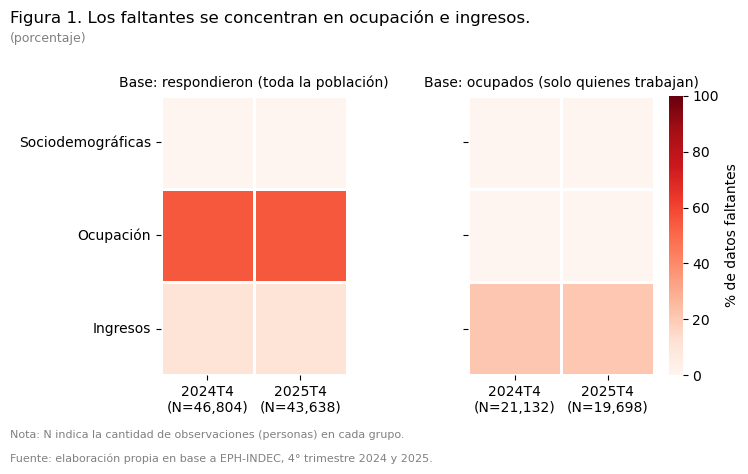

In [59]:
# Inciso 7: heatmap de faltantes AGRUPADO por tipo de variable (Schwabish: reducir clutter)

# Definimos grupos de variables según su naturaleza
grupos = {
    'Sociodemográficas': ['CH04','CH06','CH07','CH08','NIVEL_ED'],
    'Ocupación': ['EMPLEO','SECTOR','PP04C','PP04D_COD','PP05I','PP05K','PP04A','PP3E_TOT','INTENSI'],
    'Ingresos': ['P21','P47T'],
}

def faltantes_por_grupo(df):
    """% promedio de faltantes de cada grupo, por año."""
    filas = {}
    for nombre, vars_g in grupos.items():
        filas[nombre] = df.groupby('ANO4')[vars_g].apply(lambda x: x.isna().mean().mean() * 100)
    return pd.DataFrame(filas).T

tabla_resp = faltantes_por_grupo(respondieron)
tabla_ocup = faltantes_por_grupo(ocupados)

# Renombramos columnas con el N incluido (Schwabish: integrar texto y gráfico)
n_resp = respondieron.groupby('ANO4').size()
n_ocup = ocupados.groupby('ANO4').size()
tabla_resp.columns = [f'2024T4\n(N={n_resp[2024]:,})', f'2025T4\n(N={n_resp[2025]:,})']
tabla_ocup.columns = [f'2024T4\n(N={n_ocup[2024]:,})', f'2025T4\n(N={n_ocup[2025]:,})']

# Dos paneles, mismos grupos, para comparar las dos bases
fig, axes = plt.subplots(1, 2, figsize=(7.6, 4), sharey=True)
sns.heatmap(tabla_resp, annot=False, cmap='Reds', vmin=0, vmax=100,
            cbar=False, ax=axes[0], linewidths=1, square=True)
axes[0].set_title("Base: respondieron (toda la población)", fontsize=10)
axes[0].set_ylabel(""); axes[0].tick_params(axis='y', rotation=0)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontweight='normal')
sns.heatmap(tabla_ocup, annot=False, cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '% de datos faltantes'}, ax=axes[1], linewidths=1, square=True)
axes[1].set_title("Base: ocupados (solo quienes trabajan)", fontsize=10)
axes[1].set_ylabel("")
# Título a la izquierda + subtítulo aclaratorio en gris
fig.suptitle("Figura 1. Los faltantes se concentran en ocupación e ingresos.",
             fontsize=12, x=0.02, ha='left', y=1.05)
fig.text(0.02, 0.97, "(porcentaje)", fontsize=9, color='gray', ha='left')
# Fuente al pie
fig.text(0.02, -0.08,
         "Nota: N indica la cantidad de observaciones (personas) en cada grupo.\n\nFuente: elaboración propia en base a EPH-INDEC, 4° trimestre 2024 y 2025.",
         fontsize=8, color='gray', ha='left')
plt.subplots_adjust(wspace=0.05)
plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
plt.savefig('output/fig1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Tabla 1.** Porcentaje de valores faltantes por variable, base y año.

In [60]:
# Tabla detallada de faltantes por variable (respaldo del heatmap agrupado)
det_resp = respondieron.groupby('ANO4')[vars_interes].apply(lambda x: x.isna().mean() * 100).T
det_ocup = ocupados.groupby('ANO4')[vars_interes].apply(lambda x: x.isna().mean() * 100).T

det_resp.index = [etiquetas[v] for v in det_resp.index]
det_ocup.index = [etiquetas[v] for v in det_ocup.index]

tabla_detalle = pd.concat(
    [det_resp, det_ocup],
    axis=1,
    keys=['respondieron', 'ocupados']
).round(1)

# Damos formato: nombres de variables a la izquierda, números centrados
tabla_detalle.style \
    .format('{:.1f}') \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
        {'selector': 'th.col_heading', 'props': [('text-align', 'center')]},
    ])

*Fuente: Elaboración propia en base a EPH-INDEC, 4° trimestre 2024 y 2025.*